In [1]:
%pip install "numpy<2.0" "opencv-python==4.8.0.74" "cellpose<4.0" -q
%pip install pyocclient -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 MB 13.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 94.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.4/226.4 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 108.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 71.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 12.1 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 

In [2]:
import owncloud, getpass, cellpose

# Config
url, user = 'https://cloud.minesparis.psl.eu', 'gabriel.gautier'
oc_session = owncloud.Client(url)
oc_session.login(user, getpass.getpass(f"PW {user}: "))
oc_session.get_file('/travail/Mines/DIMA/Segmentation/scripts/tool.py', 'tool.py')

import tool
oc = tool.Owncloud(oc_session)

print("Tool chargé et prêt.")

Tool chargé et prêt.


In [1]:
!nvcc --version
!nvidia-smi

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
Fri Mar 20 09:43:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8       

In [3]:
oc.upload_data()

In [4]:
import os, shutil
import numpy as np
import matplotlib.pyplot as plt
import cv2

from cellpose import core, utils, io, models, metrics, train, dynamics
from glob import glob

import importlib

In [5]:
oc.upload_scripts()
oc.upload_models()
importlib.reload(tool)
import tool

visualizer = tool.CellVisualizer()

In [6]:
use_GPU = core.use_gpu()
yn = ['NO', 'YES']
print(f'>>> GPU activated? {yn[use_GPU]}')

>>> GPU activated? YES


In [5]:

io.logger_setup()

model = models.CellposeModel(gpu=True, model_type="cyto3")

path = '001'
img = visualizer.load_data(path, mode='Image')

masks, flows, styles = model.eval(img, 
                                  diameter=65, 
                                  channels=[0,0],
                                  resample=True)


output_dir = './data/processed/cellpose/annotation'
os.makedirs(output_dir, exist_ok=True)

filename = os.path.basename(path)
name_without_ext = os.path.splitext(filename)[0]
save_path = os.path.join(output_dir, f"{name_without_ext}_Cell_pred.bmp")

cv2.imwrite(save_path, masks)

print(f"Masque sauvegardé : {save_path}")

NameError: name 'io' is not defined

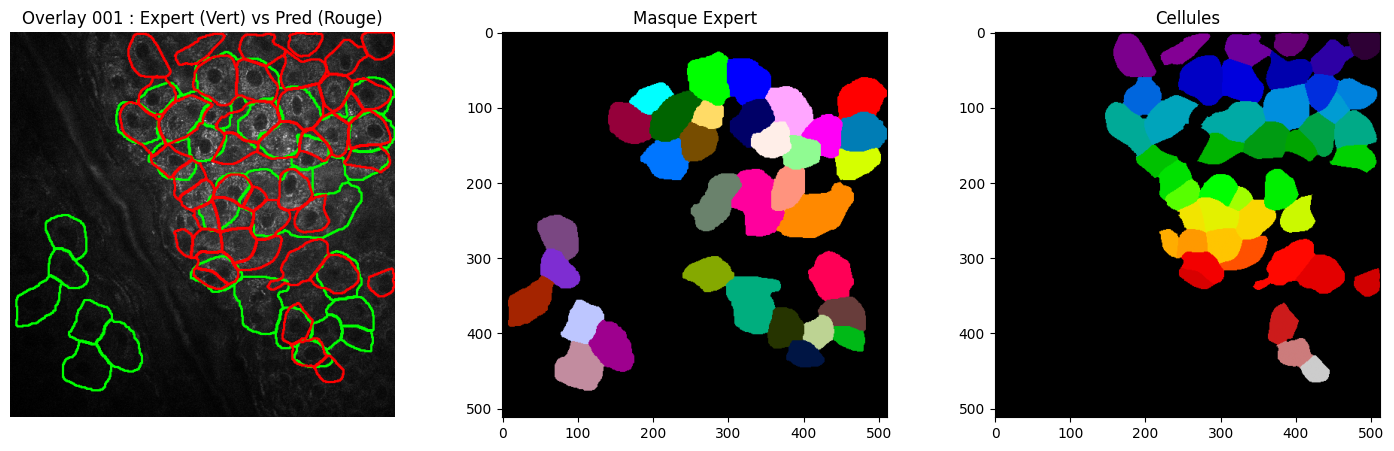

[Cellpose] F1: 0.100 | TP: 3 | FN: 12


{'f1': 0.10000000149011612,
 'ap': 0.05263157933950424,
 'tp': 3,
 'fp': 42,
 'fn': 12}

In [6]:
true_mask = visualizer.load_data("001", mode='Cell')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
visualizer.plot_overlay(i = "001", mask_pred=masks, ax=ax1, show=False)
visualizer.plot(data = masks, mode = 'Cell_pred', ax=ax3, show=False)
visualizer.plot(i = "001", mode='Cell', ax=ax2, show=False, title="Masque Expert")
plt.show()


ev = tool.Stats()
ev.report("Cellpose", true_mask, masks)


In [ ]:

import random


my_ids = ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010','011', '012', '013', '014', '015', '016', '017', '018', '019', '020','021', '022', '023', '024', '025', '026', '027', '028', '029', '030','031', '032', '033', '034', '035', '036', '037', '038', '039', '040','041', '042', '043', '044', '045', '046', '047', '048', '049', '050'] 


random.seed(42)
random.shuffle(my_ids)

n = len(my_ids)
ids_train = my_ids[:int(0.7 * n)]
ids_val   = my_ids[int(0.7 * n):int(0.8 * n)]
ids_test  = my_ids[int(0.8 * n):]

print(f"Split : Train({len(ids_train)}) | Val({len(ids_val)}) | Test({len(ids_test)})")



Split : Train(71) | Val(10) | Test(21)



--- Test LR = 0.07 ---


100%|██████████| 10/10 [00:00<00:00, 782.08it/s]


-> Val Loss : 0.0000

--- Test LR = 0.05 ---


100%|██████████| 10/10 [00:00<00:00, 722.20it/s]


-> Val Loss : 0.0000

--- Test LR = 0.03 ---


100%|██████████| 10/10 [00:00<00:00, 795.28it/s]


-> Val Loss : 0.0000


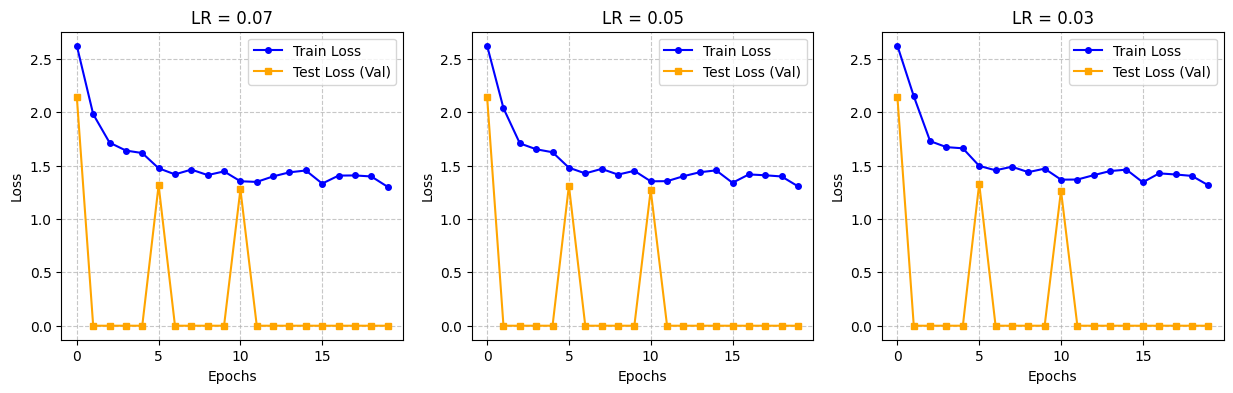

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from cellpose import train, models, io


X_train, Y_train = visualizer.load_set(ids_train)
X_val, Y_val     = visualizer.load_set(ids_val)
X_test, Y_test   = visualizer.load_set(ids_test)

# 2. Boucle minimaliste sur les LR
io.logger_setup()
learning_rates = [0.1, 0.05, 0.01] 
fig, axes = plt.subplots(1, len(learning_rates), figsize=(15, 4))

for i, lr in enumerate(learning_rates):
    print(f"\n--- Test LR = {lr} ---")
    
    model = models.CellposeModel(model_type='cyto3', gpu=True)
    
    m_path, t_loss, v_loss = train.train_seg(
        model.net,
        train_data=X_train, train_labels=Y_train,
        test_data=X_val, test_labels=Y_val,
        channels=[0,0],
        n_epochs=20,         
        learning_rate=lr,
        weight_decay=0.0001,
        save_path='.',
        model_name=f'cyto3_lr_{lr}'
    )
    
    final_val_loss = v_loss[-1]
    print(f"-> Val Loss : {final_val_loss:.4f}")
    visualizer.plot_loss(t_loss, v_loss, title=f"LR = {lr}", ax=axes[i], show=False)
    

plt.show()


In [7]:
import json

with open('./data/dataset_splits.json', 'r') as f:
    splits = json.load(f)

ids_train = splits['train']
ids_val   = splits['val']
ids_test  = splits['test']

print(f"Splits chargés : Train({len(ids_train)}) | Val({len(ids_val)}) | Test({len(ids_test)})")

Splits chargés : Train(71) | Val(10) | Test(21)


creating new log file


100%|██████████| 25.3M/25.3M [00:01<00:00, 22.4MB/s]
100%|██████████| 10/10 [00:00<00:00, 587.04it/s]


Modèle sauvegardé : models/cyto3_60


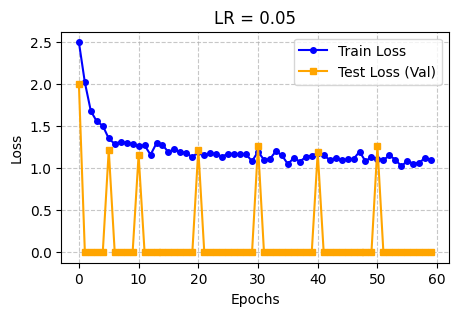

<Axes: title={'center': 'LR = 0.05'}, xlabel='Epochs', ylabel='Loss'>

In [7]:
import matplotlib.pyplot as plt
from cellpose import train, models, io

X_train,Y_train = visualizer.load_set(ids_train)
X_val,Y_val   = visualizer.load_set(ids_val)

io.logger_setup()
model_finetune = models.CellposeModel(model_type='cyto3', gpu=True)

model_path, t_loss, v_loss = train.train_seg(
    model_finetune.net,
    train_data=X_train,
    train_labels=Y_train,
    test_data=X_val,
    test_labels=Y_val,
    channels=[0,0],
    n_epochs=60,          
    learning_rate=0.05,
    weight_decay=0.0001,  
    save_path='.',
    model_name='cyto3_60'
)

print(f"Modèle sauvegardé : {model_path}")

visualizer.plot_loss(t_loss, v_loss, title=f"LR = {0.05}",show=True)


In [11]:
oc.oc.put_file(
    '/travail/Mines/DIMA/Segmentation/results/models/cyto3_60.pth',
    model_path                                  
)

True

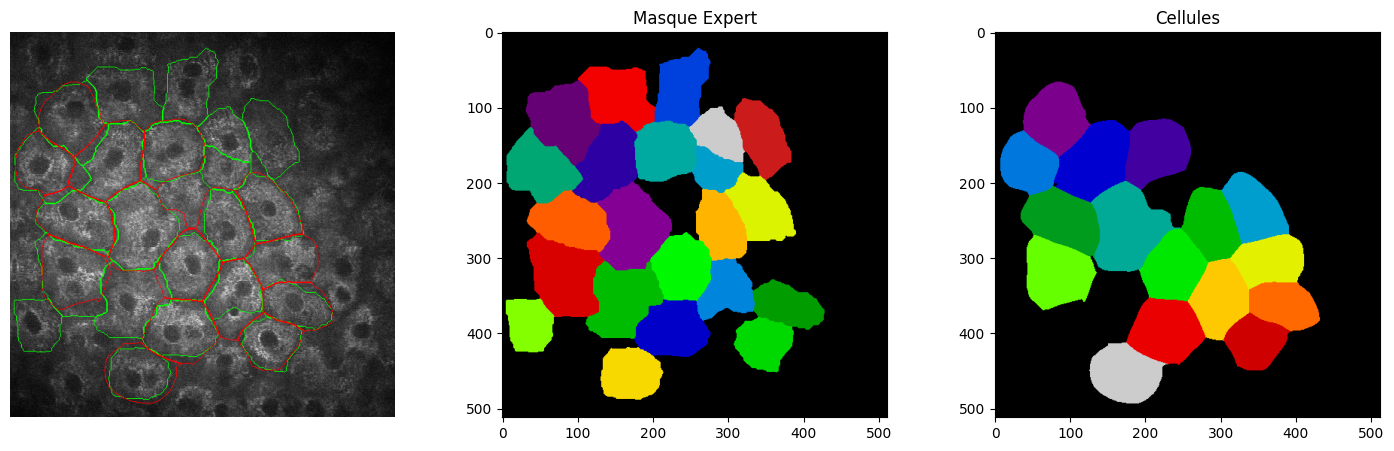


RESULTATS GLOBAUX : Cellpose cyto3
Images evaluees          : 21
Total Vrais Positifs (TP): 265
Total Faux Positifs (FP) : 26
Total Faux Negatifs (FN) : 372
--------------------------------------------------
F1-Score Global (Micro)  : 0.571
F1-Score Moyen (Macro)   : 0.542



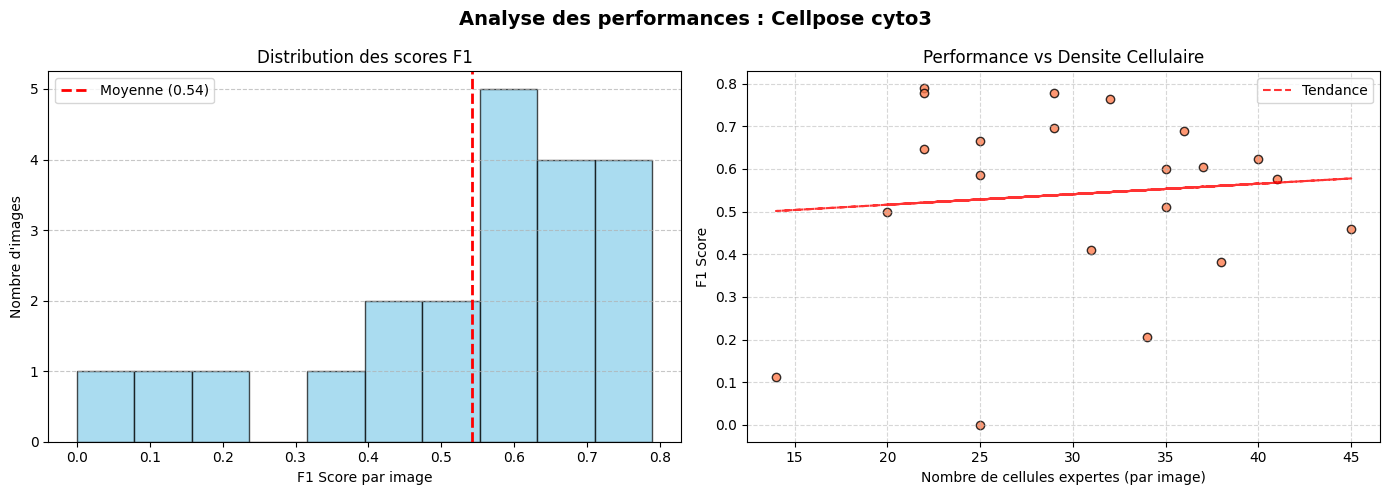

In [12]:
io.logger_setup()
model = models.CellposeModel(gpu=True, pretrained_model= './models/cyto3_60.pth')

output_dir = './data/prediction/cellpose3_60/'
os.makedirs(output_dir, exist_ok=True)

ev = tool.Stats()

all_results = [] 

for img_id in ids_test:
    img = visualizer.load_data(img_id, mode='Image')
    true_mask = visualizer.load_data(img_id, mode='Cell')
    
    masks, flows, styles = model.eval(img, channels=[0,0], resample=True)
    
    save_path = os.path.join(output_dir, f"{img_id}_Cell_pred.bmp")
    cv2.imwrite(save_path, masks)

    all_results.append(ev.report("Cellpose", true_mask, masks, show=False))

    
    if img_id == '065':
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
        visualizer.plot_overlay(i=img_id, mask_pred=masks, ax=ax1, show=False)
        visualizer.plot(data=masks, mode='Cell_pred', ax=ax3, show=False)
        visualizer.plot(i=img_id, mode='Cell', ax=ax2, show=False, title="Masque Expert")
        plt.show()

df_final = ev.global_report(all_results, model_name="Cellpose cyto3")

In [13]:
oc.download_path('/content/data/prediction/cellpose3_60/','/travail/Mines/DIMA/Segmentation/data/prediction/cellpose3_60/')

Dossier cellpose3_60 envoyé vers /travail/Mines/DIMA/Segmentation/data/prediction/cellpose3_60/.zip
